## **Exploratory Data Analysis (EDA)**

In [153]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [154]:
# 2. Carga del conjunto de datos
df = pd.read_csv(
    r'C:\Users\LENOVO\Documentos\Marco\Data-Science\ar_properties.csv')


In [155]:
# Inspección inicial
df.head(3)  # Visualización de las primeras filas del dataset

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,wdQ5hWhv8P14T7Sh9g4QCg==,Propiedad,2020-12-25,9999-12-31,2020-12-25,-32.716652,-68.642692,Argentina,Mendoza,NaN,...,NaN,350.0,350.0,NaN,NaN,NaN,Excelentes Lotes Sobre Ruta 34,Corredor Responsable: VICTOR E. MONTIVERO - C....,Lote,Venta
1,nnMBYZ4RMRY+vm753EtA+g==,Propiedad,2020-12-25,9999-12-31,2020-12-25,-24.797723,-65.467514,Argentina,Salta,NaN,...,NaN,1541.0,1541.0,NaN,NaN,Mensual,TERRENO + VENTA + JARDINES DE SAN LORENZO +150...,Corredor Responsable: Pablo Castañeda - C.U.C....,Lote,Venta
2,+dnVA1K6JxzL1zAjOEQ1pA==,Propiedad,2020-12-25,2020-12-29,2020-12-25,-34.919373,-58.020591,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,...,NaN,1000.0,1000.0,NaN,NaN,Mensual,Lote en Venta de 1000 m2 en La Plata,Corredor Responsable: Rico Sebastián - Martill...,Lote,Venta


Variable 'id', 'title' y 'description' no contienen información relevante

In [156]:
df.info() # Información del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1000000 non-null  object 
 1   ad_type          1000000 non-null  object 
 2   start_date       1000000 non-null  object 
 3   end_date         1000000 non-null  object 
 4   created_on       1000000 non-null  object 
 5   lat              849189 non-null   float64
 6   lon              848255 non-null   float64
 7   l1               1000000 non-null  object 
 8   l2               1000000 non-null  object 
 9   l3               946673 non-null   object 
 10  l4               239496 non-null   object 
 11  l5               5001 non-null     object 
 12  l6               0 non-null        float64
 13  rooms            526423 non-null   float64
 14  bedrooms         466213 non-null   float64
 15  bathrooms        776733 non-null   float64
 16  surface_total    37

Variable 'l6' no contiene valores por lo que será eliminada. Se analizará acción a tomar con valores nulos

In [157]:
df.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'price', 'currency', 'price_period',
       'title', 'description', 'property_type', 'operation_type'],
      dtype='object')

In [158]:
df.describe()

,lat,lon,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,849189.000000,848255.000000,0.0,526423.000000,466213.000000,776733.000000,379501.000000,3.814510e+05,9.630980e+05
mean,-34.790048,-59.256701,NaN,2.861982,2.104534,1.707951,514.889481,6.123054e+03,3.285948e+05
std,2.957449,2.638051,NaN,1.689448,2.399252,1.080390,4372.302647,3.477565e+06,1.192329e+07
min,-54.841484,-119.699390,NaN,1.000000,-16.000000,1.000000,-136.000000,-1.300000e+02,0.000000e+00
25%,-34.919952,-58.746835,NaN,2.000000,1.000000,1.000000,50.000000,4.500000e+01,4.200000e+04
50%,-34.611445,-58.448442,NaN,3.000000,2.000000,1.000000,95.000000,7.600000e+01,9.800000e+04
75%,-34.456179,-58.172063,NaN,4.000000,3.000000,2.000000,255.000000,1.640000e+02,2.100000e+05
max,85.051129,-1.981231,NaN,40.000000,900.000000,20.000000,200000.000000,2.147484e+09,1.000000e+10


Valores irreales (negativos o extremos). Se analizará acción a tomar

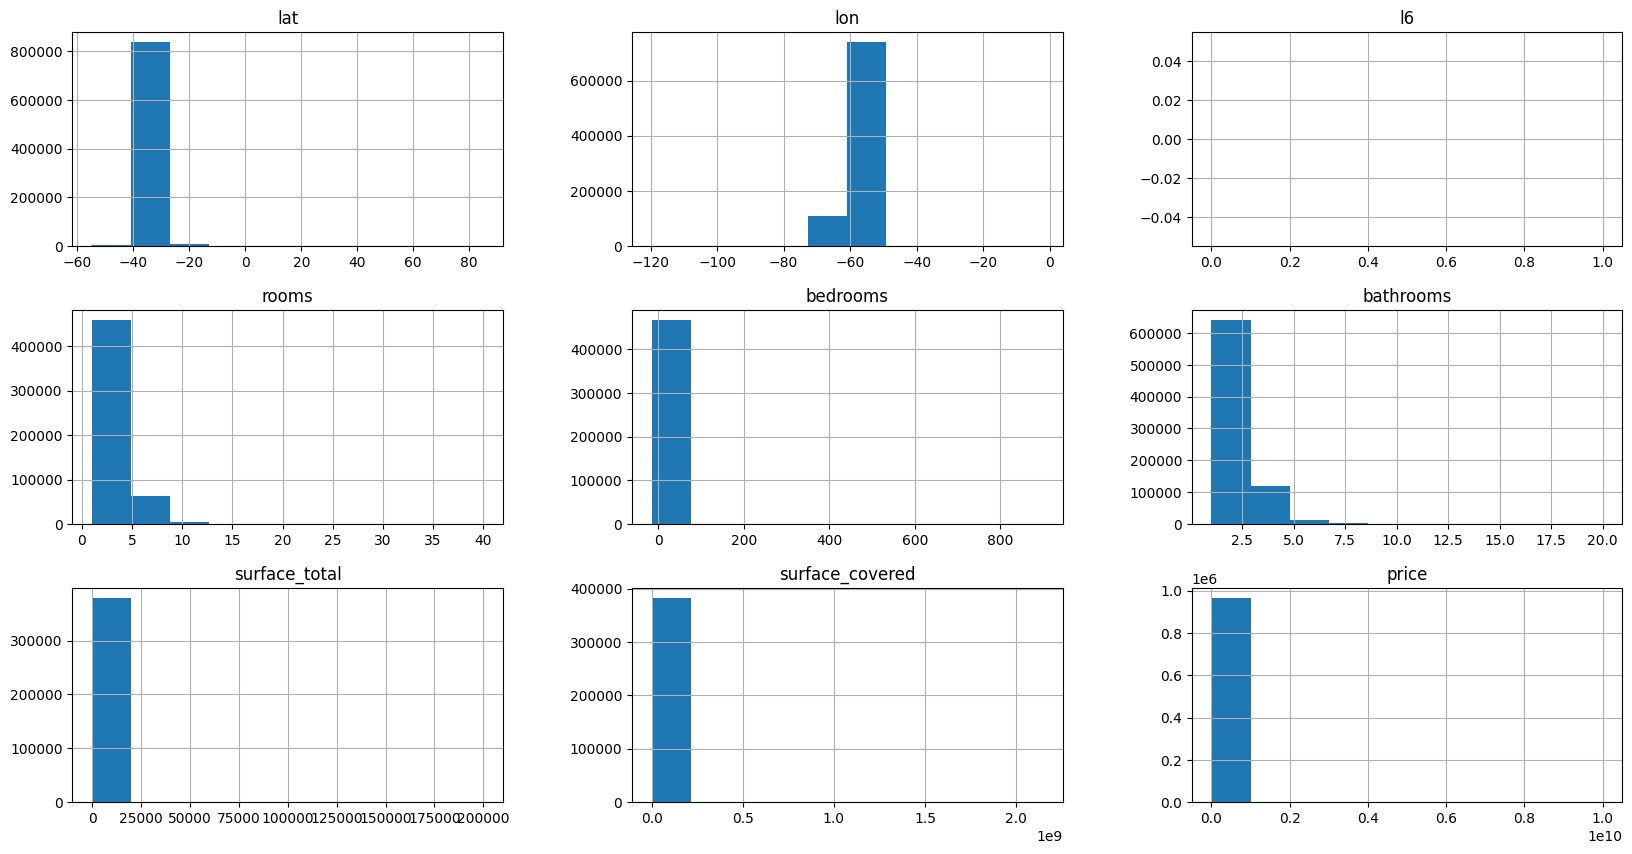

In [159]:
df.hist(figsize=(20,10))
plt.show()

#### **Se puede analizar algunas cuestiones:**

    - Contiene un millón de datos. Se pueden eliminar filas para reducir el tamaño del dataset y poder trabajar más rápido
    - 25 columnas de las cuales algunas no son relevantes para el análisis
    - Algunas de sus variables presentan una gran cantidad de valores nulos o sin sentido

#### Al haber tantos valores, se deduce que el trabajo requiere una gran limpieza de datos

### **Limpieza de datos**

In [160]:
df = df.drop(['l6'], axis=1, errors='ignore')  # Drop columna 'l6'

# Eliminación de valores faltantes en la columna 'price'
df = df[df['price'].notnull() == True]
df.shape

(963098, 24)

##### Información de variables

In [161]:
df['ad_type'].value_counts() # Valores y cantidad de la columna 'ad_type'

ad_type
Propiedad    963098
Name: count, dtype: int64

Ya que contiene un solo valor, se elimina la columna

In [162]:
df = df.drop('ad_type', axis=1, errors='ignore') # Drop columna 'ad_type'


In [163]:
df['operation_type'].value_counts() # Valores y cantidad de la columna 'operation_type'

operation_type
Venta                755922
Alquiler             177278
Alquiler temporal     29898
Name: count, dtype: int64

Se elimina 'Alquiler temporal ya que contiene pocos datos y alivianar el dataset

In [164]:
df = df[~(df['operation_type'] == 'Alquiler temporal')] # Drop filas donde 'operation_type' sea 'Alquiler temporal'


In [165]:
df['l1'].value_counts() # Valores y cantidad de la columna 'l1'

l1
Argentina         921386
Uruguay            11056
Estados Unidos       671
Brasil                87
Name: count, dtype: int64

Se eliminan todos los valores fuera de Argentina

In [166]:
df = df[df['l1'] == 'Argentina']


In [167]:
df['property_type'].value_counts() # Valores y cantidad de la columna 'property_type'

property_type
Departamento       337813
Otro               235701
Casa               164751
Lote                77573
PH                  33526
Local comercial     31807
Oficina             24873
Cochera              8015
Depósito             6043
Casa de campo        1284
Name: count, dtype: int64

Se toman en cuenta simplemente los departamentos, casas y PHs ya que algunas variables no tienen sentido para las demás propiedades

In [168]:
df = df[(df['property_type'] == 'Departamento') | (
    df['property_type'] == 'Casa') | (df['property_type'] == 'PH')]


In [169]:
df['price_period'].value_counts() # Valores y cantidad de la columna 'price_period'

price_period
Mensual    178057
Name: count, dtype: int64

Esta variable contiene muchos nulos y es única. No tiene sentido para las ventas, solo para los alquileres. Se analizan sus valores nulos para ver como reemplazarlos

In [170]:
df[(df['price_period'].notnull() == True) & (df['operation_type'] == 'Venta')] # Filtrar df cuando 'price_period' sea no sea nulo y el tipo de operación sea 'Venta'


,id,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
105,04BIHOV3jXM7kfvvGhQobA==,2020-12-25,9999-12-31,2020-12-25,-34.911570,-57.960462,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,NaN,...,1.0,38.0,35.0,58000.0,USD,Mensual,Venta estrenar monoambiente céntrico - 42 e90 ...,Exclente calidad a estrenar. Living comedor am...,Departamento,Venta
125,7xPhNLJLLmNKrY+4SKX8IA==,2020-12-25,9999-12-31,2020-12-25,-32.950769,-60.649344,Argentina,Santa Fe,Rosario,NaN,...,1.0,49.0,49.0,50000.0,USD,Mensual,Departamento - Centro,Departamento de 1 dormitorio en excelente esta...,Departamento,Venta
128,aKFPRiO492YjfMpjh+ToMw==,2020-12-25,9999-12-31,2020-12-25,-34.911694,-57.960537,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,...,1.0,50.0,48.0,80000.0,USD,Mensual,Venta estrenar 1 dormitorio - 42 e9 y 10 - La ...,Excelente calidad a estrenar. Living comedor a...,Departamento,Venta
129,dBQJF3UGwaki8pSmUsCRUA==,2020-12-25,9999-12-31,2020-12-25,-34.922166,-57.959022,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,...,1.0,45.0,43.0,75000.0,USD,Mensual,Venta depto. 1 dorm. - 49 e15 y 16 - La Plata,Al frente tipo pasante. Living comedor con bal...,Departamento,Venta
131,L2WYRjQu5PA9QzlodPmAXg==,2020-12-25,2021-01-13,2020-12-25,-34.918987,-57.939761,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,La Plata,...,1.0,43.0,41.0,45000.0,USD,Mensual,Venta depto. 1 dormitorio - Av. 60 esq. 5 - La...,"Piso alto, excelente vista y luminosidad. Livi...",Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999967,Ibh4/GGySBkn25hfpGTjVw==,2020-05-12,2020-09-28,2020-05-12,-34.552132,-58.438501,Argentina,Capital Federal,Belgrano,NaN,...,5.0,580.0,580.0,1111111.0,USD,Mensual,Casa en Forum Alcorta - Terraza con parrilla y...,"Casa en Forum Alcorta con pileta, quincho con ...",Departamento,Venta
999970,n/lYkZAxeO5cdERyaiKKew==,2020-05-12,9999-12-31,2020-05-12,-34.464697,-58.612132,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,Laguna del Sol,...,3.0,NaN,234.0,420000.0,USD,Mensual,Casa - Laguna Del Sol,¡Muy linda casa de ladrillo a la vista! Precio...,Casa,Venta
999979,jv4GGNaOj/Z506CJFuiPUw==,2020-05-12,2020-05-20,2020-05-12,-34.602115,-58.405980,Argentina,Capital Federal,Once,NaN,...,1.0,180.0,180.0,299001.0,USD,Mensual,Depto.tipo casa de 8 ambientes en Venta en Once,Departamento tipo casa a reciclar primer piso ...,PH,Venta
999980,zLEstdC80JAinfcLGQz5/Q==,2020-05-12,2020-05-20,2020-05-12,-34.415320,-58.645990,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,...,8.0,800.0,800.0,3800000.0,USD,Mensual,Casa en venta al lago central,Imponente casa en la mejor cuadra del barrio E...,Casa,Venta


In [171]:
df[(df['price_period'].notnull() == False) & (df['operation_type'] == 'Alquiler')] # Filtrar df cuando 'price_period' sea nulo y la operación 'Alquiler'

,id,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
36,OW0NuZD/PnmfUBUx6icAAA==,2020-12-25,2021-01-08,2020-12-25,-34.591216,-58.406686,Argentina,Capital Federal,Recoleta,NaN,...,1.0,17.0,17.0,15000.0,ARS,NaN,Monoambiente en alquiler en Recoleta CABA,Corredor Responsable: Daniel Acosta - CUCICBA ...,Departamento,Alquiler
37,0Gq0cAPakjVmW6x5gKpZvA==,2020-12-25,2021-01-08,2020-12-25,-34.637904,-58.502219,Argentina,Capital Federal,Villa Luro,NaN,...,1.0,38.0,36.0,24000.0,ARS,NaN,Alquiler Monoambiente Villa Luro + Amenities,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Alquiler
41,q1K3jCNN5AZ8MnwWj3Ko9g==,2020-12-25,2021-01-05,2020-12-25,-34.720874,-58.278099,Argentina,Bs.As. G.B.A. Zona Sur,Quilmes,Quilmes,...,1.0,45.0,45.0,16000.0,ARS,NaN,ALQUILER. DPTO 2 AMB. CON COCHERA. QUILMES,Corredor Responsable: Martin Veltri - C.M.Q. 8...,Departamento,Alquiler
45,kDb3k24QzbWd4lNkyerUpw==,2020-12-25,2021-01-02,2020-12-25,-34.591263,-58.410973,Argentina,Capital Federal,Recoleta,NaN,...,1.0,39.0,38.0,21000.0,ARS,NaN,"Alquiler Departamento 2 ambientes,Interno Reco...",Corredor Responsable: MARIANO AUFSEHER - CPI 4...,Departamento,Alquiler
46,kKhQd6uvRE8ZXq8PIUGi6w==,2020-12-25,2020-12-29,2020-12-25,-38.946141,-68.049174,Argentina,Neuquén,Confluencia,NaN,...,1.0,60.0,58.0,55000.0,ARS,NaN,DEPARTAMENTO UN DORMITORIO AMUEBLADO,Corredor Responsable: SEBASTIAN BONIFACIO - N°...,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998236,pY9FLVH0iaDBpMeVc6TcOw==,2020-05-12,2020-05-20,2020-05-12,NaN,NaN,Argentina,Córdoba,Córdoba,NaN,...,2.0,NaN,NaN,1100.0,USD,NaN,Departamento - Villa Morra,Departamento en Alquiler de 2 dorm. en Cordoba,Departamento,Alquiler
998239,idpn3Rt81swpDpB74jiZcQ==,2020-05-12,2020-05-20,2020-05-12,NaN,NaN,Argentina,Córdoba,Córdoba,NaN,...,1.0,NaN,39.0,650.0,USD,NaN,"Departamentos en alquiler 1 dorm, Asunción des...",Departamento en Alquiler de 1 dorm. en Cordoba,Departamento,Alquiler
998240,JNx1pkXKY5zB43WvKPdj5Q==,2020-05-12,2020-05-20,2020-05-12,NaN,NaN,Argentina,Córdoba,Córdoba,NaN,...,2.0,NaN,NaN,900.0,USD,NaN,Departamento - Villa Morra,Departamento en Alquiler de 2 dorm. en Cordoba,Departamento,Alquiler
999681,b3XeKtpIatPjNb63F7Uw6Q==,2020-05-12,2020-06-19,2020-05-12,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Norte,San Isidro,San Isidro,...,2.0,421.0,320.0,800.0,USD,NaN,"Casa 421m² con Cochera en TEJEDOR, Carlos 300,...",IMPECABLE!!!! Ecelente casa: Hall de distribuc...,Casa,Alquiler


Se tomará decisión más adelante de qué hacer con la variable 'price_period'

In [172]:
# Chequeo duplicados

df[df.duplicated(subset=None)]



,id,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type


No hay datos duplicados en el dataset. Se investigará si sacando la variable 'id' se encuentran datos repetidos.

In [173]:
col = df.drop('id', axis=1, errors='ignore')
duplicados = df[col.duplicated(subset=col.columns)]
duplicados

,id,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
43,UClZDZjF9Z4lOhP85mQSfA==,2020-12-25,2020-12-25,2020-12-25,-31.427785,-64.190612,Argentina,Córdoba,Córdoba,Nueva Córdoba,...,1.0,NaN,NaN,15000.0,ARS,Mensual,B° NUEVA CÓRDOBA – DPTO. EN ALQUILER – 1 DORMI...,Ubicación: Obispo Trejo 1076 – Frente\r\n\r\nD...,Departamento,Alquiler
44,zTUNOcXYK6YS09xF4/3GYQ==,2020-12-25,2020-12-25,2020-12-25,-31.427785,-64.190612,Argentina,Córdoba,Córdoba,Nueva Córdoba,...,1.0,NaN,NaN,15000.0,ARS,Mensual,B° NUEVA CÓRDOBA – DPTO. EN ALQUILER – 1 DORMI...,Ubicación: Obispo Trejo 1076 – Frente\r\n\r\nD...,Departamento,Alquiler
1059,tPaM266SjC+0ECaP3CBtCw==,2021-01-01,9999-12-31,2021-01-01,-34.814775,-58.465234,Argentina,Bs.As. G.B.A. Zona Sur,Esteban Echeverría,Monte Grande,...,1.0,NaN,NaN,26000.0,ARS,Mensual,Departamento - Monte Grande,HERMOSO DEPTO EN MONTE GRANDE<br>ZONA CENTRICA...,Departamento,Alquiler
1109,raUWyJb05ATWGWfVqppkyg==,2021-01-01,9999-12-31,2021-01-01,-34.544221,-58.547588,Argentina,Bs.As. G.B.A. Zona Norte,General San Martín,Villa Ballester,...,1.0,90.0,40.0,90000.0,USD,NaN,Departamento de 2 ambientes con terraza,Increble departamento de 2 ambientes a estrena...,Departamento,Venta
1186,Xu7z0i7uHa2xnILKT0zRzw==,2021-01-01,2021-01-13,2021-01-01,-34.658966,-58.618633,Argentina,Bs.As. G.B.A. Zona Oeste,Morón,Morón,...,1.0,30.0,28.0,14000.0,ARS,Mensual,"Departamento de un ambiente en alquiler, Morón.",EXCELENTE DEPARTAMENTO DE UN AMBIENTE CON BALC...,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998238,TFV9QkQO2imC/RHlwMaGuw==,2020-05-12,2020-11-26,2020-05-12,NaN,NaN,Argentina,Córdoba,Córdoba,NaN,...,3.0,NaN,186.0,410000.0,USD,NaN,Vilanova villa Belgrano deptos en venta / alqu...,Departamento en Venta de 3 dorm. en Cordoba,Departamento,Venta
999407,tavYa+m5HLdpEQ0mjwzQlw==,2020-05-12,2020-05-20,2020-05-12,-34.610187,-58.423543,Argentina,Capital Federal,Almagro,NaN,...,2.0,65.0,62.0,123000.0,USD,Mensual,Departamento de 3 ambientes en Venta en Almagro,"NEGOCIABLE!!!, Hermoso 3 ambientes al contrafr...",Departamento,Venta
999422,jHaSNnXsUykqRszEJWnaYw==,2020-05-12,2020-05-20,2020-05-12,-34.575921,-58.421206,Argentina,Capital Federal,Palermo,NaN,...,2.0,130.0,130.0,3300.0,USD,Mensual,U$S 3.300 - 3 amb amoblado - Cochera - Palermo...,PRECIO PAQUETEExpensas y ABL incluido.QUARTIER...,Departamento,Alquiler
999632,ExAsZ2eX+4NXGQIC8arX9g==,2020-05-12,2020-05-20,2020-05-12,-34.402698,-58.663971,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,Nordelta,...,3.0,671.0,220.0,410000.0,USD,Mensual,CASA A ESTRENAR EN VENTA EN BARRIO LOS LAGOS -...,"Casa de reconocida constructora, en venta en B...",Casa,Venta


In [174]:
# Nuevo dataframe sin valores repetidos y drop columna 'id'
df = df.drop_duplicates(subset=col.columns)
df = df.drop('id', axis=1, errors='ignore')


In [175]:
df[df['start_date'] != df['created_on']] # Chequeo si la columna 'start_date' es igual a la columna 'created_on'

,start_date,end_date,created_on,lat,lon,l1,l2,l3,l4,l5,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type


Son iguales por lo tanto se elimina la columna 'created_on'

In [176]:
df = df.drop('created_on', axis=1, errors='ignore') # Eliminación de columna 'created_on'


In [181]:
# Eliminación de filas con muy poca información
df = df[~((df['rooms'].isnull() == True) & (df['bedrooms'].isnull() == True))]


##### Inspección de valores irreales

In [182]:
df.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,410495.000000,409834.000000,422988.000000,377409.000000,440359.000000,248620.000000,2.727840e+05,4.643350e+05
mean,-34.487333,-59.281736,2.910501,2.136703,1.669665,225.958793,8.014011e+03,3.695015e+05
std,1.872624,2.305539,1.548555,2.079842,1.010632,1872.535065,4.111691e+06,1.571953e+07
min,-54.831793,-117.062771,1.000000,-16.000000,1.000000,-136.000000,-1.300000e+02,0.000000e+00
25%,-34.702471,-58.703240,2.000000,1.000000,1.000000,50.000000,4.500000e+01,5.500000e+04
50%,-34.597686,-58.471734,3.000000,2.000000,1.000000,80.000000,7.100000e+01,1.150000e+05
75%,-34.461085,-58.399356,4.000000,3.000000,2.000000,176.000000,1.400000e+02,2.200010e+05
max,42.351662,-2.539603,40.000000,900.000000,20.000000,194273.000000,2.147484e+09,1.000000e+10


Variables 'bedrooms', 'surface_total', 'surface_covered' y 'price' con valores sin sentido

In [183]:
df[df['bedrooms'] < 0]


,start_date,end_date,lat,lon,l1,l2,l3,l4,l5,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
49558,2020-06-04,2020-06-30,-34.577927,-58.422944,Argentina,Capital Federal,Palermo,NaN,NaN,NaN,...,1.0,48.0,45.0,25000.0,ARS,NaN,Excelente Dos ambientes en Palermo,"Excelnte dos ambientes en dos plantas , muy lu...",Departamento,Alquiler
123648,2020-09-08,9999-12-31,-34.571572,-58.431867,Argentina,Capital Federal,Palermo,NaN,NaN,2.0,...,1.0,40.0,40.0,33000.0,ARS,NaN,Muy buen dos ambientes en alquiler temporario,"Muy buen dos ambientes , ubicada en lo mejor d...",Departamento,Alquiler
489731,2020-07-23,2020-08-18,-34.716259,-58.395588,Argentina,Bs.As. G.B.A. Zona Sur,Lanús,Remedios de Escalada,NaN,2.0,...,1.0,50.0,43.0,78500.0,USD,NaN,Venta Depto 2 ambientes con balcón y cochera e...,Venta de departamento 2 ambientes con balcón y...,Departamento,Venta
594133,2020-10-05,9999-12-31,-34.888962,-58.021431,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,Manuel B Gonnet,NaN,NaN,...,1.0,192.0,105.0,165000.0,USD,NaN,DUPLEX 3 DORMITORIOS GONNET,511 bis y 23. Complejo La Josefa de Gonnet. 6 ...,Casa,Venta
715771,2021-01-07,9999-12-31,-34.577595,-58.495185,Argentina,Capital Federal,Villa Urquiza,NaN,NaN,2.0,...,1.0,61.0,43.0,125000.0,USD,NaN,Jardines de Roosevelt - Hermoso 3 ambientes co...,Jardines de Roosevelt UF 547. Departamento de ...,Departamento,Venta
882460,2020-06-17,2020-09-08,-34.704725,-58.392517,Argentina,Bs.As. G.B.A. Zona Sur,Lanús,NaN,NaN,1.0,...,1.0,NaN,NaN,13000.0,ARS,NaN,Departamento en Alquiler en Lanus Oeste,.. Monoambiente al frente. \n=== MONOAMBIENTE ...,Departamento,Alquiler


In [184]:
df['bedrooms'] = df['bedrooms'].abs() # Cambiamos sus valores a positivos

In [185]:
df[df['surface_total'] < df['surface_covered']] 


,start_date,end_date,lat,lon,l1,l2,l3,l4,l5,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
157,2020-12-25,2020-12-29,-34.682435,-58.722986,Argentina,Bs.As. G.B.A. Zona Oeste,Merlo,Merlo,NaN,3.0,...,1.0,70.0,470.0,79900.0,USD,NaN,CASA LOTE PROPIO MERLO 3 AMB RECICLADA FONDO L...,Corredor Responsable: Mariano Menendez - CMCPM...,Casa,Venta
351,2020-12-26,2021-02-11,-34.676584,-58.685673,Argentina,Bs.As. G.B.A. Zona Oeste,Merlo,San Antonio De Padua,NaN,2.0,...,1.0,40.0,50.0,18000.0,ARS,Mensual,A 16 cuadras de la estacion P.H con1 dormitorio,"A 15 cuadras de la estación de S.A. de Padua, ...",PH,Alquiler
471,2020-12-26,9999-12-31,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Norte,NaN,NaN,NaN,4.0,...,2.0,110.0,151.0,112000.0,USD,Mensual,Casa - Los Cardales,"Casa en Venta en los Cardales barrio ""Los Car...",Casa,Venta
2053,2020-08-09,2020-08-20,-33.151512,-60.515085,Argentina,Santa Fe,Rosario,NaN,NaN,1.0,...,1.0,30.0,33.0,9000.0,ARS,NaN,MONOAMBIENTE ALQUILER BARRIO MARTIN,Corredor Responsable: Sebastian Pellegrini - C...,Departamento,Alquiler
2416,2020-08-09,2020-10-03,-34.703950,-58.374594,Argentina,Bs.As. G.B.A. Zona Sur,Lanús,Gerli,NaN,2.0,...,1.0,37.0,40.0,69000.0,USD,NaN,Exelente oportunidad . PH reciclado - Lanus,Corredor Responsable: NATALIN ODOGUARDI - CUCI...,PH,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997595,2020-05-12,2020-08-24,-31.602990,-60.701434,Argentina,Santa Fe,Santa Fe,NaN,NaN,8.0,...,2.0,150.0,160.0,5500000.0,ARS,Mensual,Casa - Santa Fe,"OPORTUNIDAD EN PESOS, CASA EN Bº DON BOSCO<br>...",Casa,Venta
997770,2020-05-12,2020-09-23,-32.999237,-58.518837,Argentina,Entre Ríos,Gualeguaychú,NaN,NaN,2.0,...,2.0,68.0,80.0,85000.0,USD,NaN,Magnasco 100 - U$D 85.000 - Casa en Venta,"Duplex a estrenar con todos los servicios, amp...",Casa,Venta
998868,2020-05-12,2020-05-20,-38.955548,-68.050891,Argentina,Neuquén,Neuquén,NaN,NaN,NaN,...,1.0,200.0,313.0,600000.0,USD,Mensual,"Venta Propiedad Apta Desarrollo Microcentro, N...",LEO SFEIR &amp; Asociados VENDE en EXCLUSIVAPR...,Casa,Venta
999212,2020-05-12,9999-12-31,-34.585268,-58.548226,Argentina,Bs.As. G.B.A. Zona Norte,General San Martín,NaN,NaN,3.0,...,1.0,113.0,130.0,100000.0,USD,NaN,VPH320 - VENTA PH 3 amb - Calle MITRE,VENTA - VPH320 - PH 3 amb al Fte. CON RENTA .<...,PH,Venta


Eliminamos para reducir dataframe

In [186]:
df = df[~(df['surface_total'] < df['surface_covered'])]


In [187]:
df[df['surface_covered'] < 15]


,start_date,end_date,lat,lon,l1,l2,l3,l4,l5,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
62,2020-12-25,9999-12-31,-34.447046,-58.631853,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,Santa Barbara Barrio Cerrado,NaN,NaN,...,1.0,NaN,1.0,5500.0,USD,NaN,SANTA BARBARA 100,ALQUILER TEMPORARIO ENERO Y FEBRERO U$S 5.500...,Casa,Alquiler
63,2020-12-25,9999-12-31,-34.447512,-58.631587,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,Santa Barbara Barrio Cerrado,NaN,NaN,...,3.0,NaN,1.0,5500.0,USD,NaN,SANTA BARBARA 100,ALQUILER TEMPORARIO ENERO Y FEBRERO U$S 5.500...,Casa,Alquiler
8457,2020-02-06,2020-10-08,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Sur,Cañuelas,Cañuelas,NaN,5.0,...,2.0,500.0,1.0,105000.0,USD,NaN,Casa en Venta Canuelas / Canuelas (A170 1784),Casa de tres ambientes mas departamento de do...,Casa,Venta
11860,2020-02-01,2020-08-01,-34.573045,-58.486058,Argentina,Capital Federal,Villa Urquiza,NaN,NaN,1.0,...,NaN,12.0,12.0,14500.0,ARS,Mensual,PH - Villa Urquiza,En ALQUILER en VILLA URQUIZA PH Monoamb ...,PH,Alquiler
11862,2020-02-01,2020-06-30,-34.781848,-58.425075,Argentina,Bs.As. G.B.A. Zona Sur,Lomas de Zamora,Llavallol,NaN,3.0,...,1.0,NaN,10.0,14000.0,ARS,Mensual,PH - Llavallol,"PH 3 ambientes con Cable en Araguaya al 1800, ...",PH,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984683,2020-02-11,2020-03-15,-34.607599,-58.945295,Argentina,Bs.As. G.B.A. Zona Oeste,General Rodríguez,General Rodríguez,NaN,NaN,...,2.0,150.0,1.0,200000.0,USD,NaN,Excelente Duplex,: Excelente duplex con detalles de calidad Pla...,Casa,Venta
986204,2020-02-11,2020-02-13,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Norte,Escobar,NaN,NaN,NaN,...,2.0,NaN,10.0,315000.0,USD,NaN,"Casa en venta Barrio Vistas, Puertos del Lago,...",Hermosa casa en venta diseñada sobre dos plant...,Casa,Venta
986628,2020-02-11,2020-02-13,-34.575048,-58.420743,Argentina,Capital Federal,Palermo,Palermo Chico,NaN,5.0,...,4.0,NaN,1.0,2500000.0,USD,NaN,EXCELENTE y EXCLUSIVO * SEMIPISO EN VENTA EN L...,ESPECTACULAR SEMIPISO SUPER LUMINOSO en las EX...,Departamento,Venta
988903,2020-07-06,9999-12-31,-34.584502,-58.444817,Argentina,Capital Federal,Palermo,NaN,NaN,2.0,...,1.0,58.0,10.0,126728.0,USD,NaN,FIDEICOMISO AL COSTO PALERMO / COLEGIALES PRE ...,OPORTUNIDAD NUEVO EMPRENDIMIENTO ”AV CÓRDOBA Y...,Departamento,Venta


Se elimina ya que por lo general su variable 'surface_total' es NaN

In [188]:
df = df[~(df['surface_covered'] < 15)]


In [189]:
df[df['price'] < 50]


,start_date,end_date,lat,lon,l1,l2,l3,l4,l5,rooms,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
1990,2020-08-09,2020-08-09,-40.154585,-71.354476,Argentina,Neuquén,NaN,NaN,NaN,2.0,...,1.0,NaN,NaN,0.0,NaN,Mensual,Grupo Patagonia VENDE DEPARTAMENTOS A ESTRENAR...,DEPARTAMENTOS A ESTRENAR COMPLETAMENTE EQUIPAD...,Departamento,Venta
4930,2020-06-15,2020-06-15,-34.578272,-58.441348,Argentina,Capital Federal,Colegiales,NaN,NaN,2.0,...,1.0,NaN,NaN,0.0,NaN,Mensual,Venta. Entrega 12/2021. Departamento 2 ambient...,CARACTERISTICAS:<br />\n<br />\n- Ambientes: 2...,Departamento,Venta
5621,2020-06-08,2020-06-08,-37.396143,-68.929359,Argentina,Neuquén,Rincón de los Sauces,NaN,NaN,35.0,...,1.0,35.0,35.0,0.0,NaN,Mensual,Alquilo departamentos amoblados.,"Inmobiliaria De La Via, ALQUILA, departamentos...",Departamento,Alquiler
5624,2020-06-08,2020-06-08,-34.428670,-58.598810,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,NaN,NaN,NaN,...,2.0,NaN,223.0,0.0,NaN,Mensual,Casa en Venta.Los Ceibos. Rincón de Milberg Ti...,"Casa muy luminosa, la mejor orientación en Imp...",Casa,Venta
5625,2020-06-08,2020-06-08,-38.350527,-68.782444,Argentina,Neuquén,Añelo,NaN,NaN,NaN,...,1.0,225.0,225.0,0.0,NaN,Mensual,Vendo complejo de 4 casas en Añelo.,"Inmobiliaria De La Via, VENDE, complejo de 4 c...",Casa,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996860,2020-05-12,2020-05-20,-34.577712,-58.436266,Argentina,Capital Federal,Palermo,Palermo Hollywood,NaN,2.0,...,1.0,68.0,56.0,0.0,NaN,Mensual,Departamento de 2 ambientes en Venta en Palerm...,AMPLIO DEPARTAMENTO 2 AMBIENTES 79 M2 TOTALES ...,Departamento,Venta
996868,2020-05-12,2020-05-20,-34.577712,-58.436266,Argentina,Capital Federal,Palermo,Palermo Hollywood,NaN,3.0,...,1.0,91.0,78.0,0.0,NaN,Mensual,Departamento de 3 ambientes en Venta en Palerm...,"DEPARTAMENTO 3 AMBIENTES AL FRENTE 91,30 M2 TO...",Departamento,Venta
996875,2020-05-12,2020-05-20,-26.826181,-65.314981,Argentina,Tucumán,Yerba Buena,NaN,NaN,3.0,...,2.0,120.0,120.0,0.0,NaN,Mensual,Increíble departamento en Veraterra Lofts ALQU...,Lindísimo departamento de dos dormitorios en V...,Departamento,Alquiler
996879,2020-05-12,2020-05-12,NaN,NaN,Argentina,Córdoba,Río Tercero,NaN,NaN,6.0,...,NaN,NaN,NaN,0.0,NaN,Mensual,Alquilo Hermosa Casa de 3 Dormitorios Interna,<br />\n <br />\n Ref#488377.,PH,Alquiler


Es la variable dependiente por lo tanto elimino filas con valores muy bajos

In [190]:
df = df[df['price'] > 50]


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 459315 entries, 36 to 999981
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       459315 non-null  object 
 1   end_date         459315 non-null  object 
 2   lat              406176 non-null  float64
 3   lon              405515 non-null  float64
 4   l1               459315 non-null  object 
 5   l2               459315 non-null  object 
 6   l3               446859 non-null  object 
 7   l4               142451 non-null  object 
 8   l5               3211 non-null    object 
 9   rooms            459296 non-null  float64
 10  bedrooms         459315 non-null  float64
 11  bathrooms        435589 non-null  float64
 12  surface_total    244353 non-null  float64
 13  surface_covered  268058 non-null  float64
 14  price            459315 non-null  float64
 15  currency         459315 non-null  object 
 16  price_period     154990 non-null  object 


Cuando la variable 'bedrooms' es 1, 

In [223]:
max_rooms = df['rooms'].max()
max_bedrooms = df['bedrooms'].max()

In [224]:
for room_count in range (0, max_rooms.astype(int)+1):
    median_bedrooms = df.loc[df['rooms'] == room_count, 'bedrooms'].median()
    df.loc[(df['rooms'] == room_count) & (df['bedrooms'].isnull()), 'bedrooms'] = median_bedrooms

In [225]:
for bedroom_count in range (0, max_bedrooms.astype(int)+1):
    median_rooms = df.loc[df['bedrooms'] == bedroom_count, 'rooms'].median()
    df.loc[(df['bedrooms'] == bedroom_count) & (df['rooms'].isnull()), 'rooms'] = median_rooms

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Us

In [232]:
df.loc[df['bathrooms'].isnull() == False,'rooms':'bathrooms']


,rooms,bedrooms,bathrooms
36,1.0,1.0,1.0
37,1.0,1.0,1.0
38,1.0,1.0,1.0
40,2.0,1.0,1.0
41,2.0,1.0,1.0
...,...,...,...
999976,7.0,6.0,3.0
999977,7.0,6.0,2.0
999979,8.0,7.0,1.0
999980,8.0,7.0,8.0


In [233]:
# Calcular la mediana de 'bathrooms' para cada combinación de 'rooms' y 'bedrooms'
median_bathrooms = df.groupby(['rooms', 'bedrooms'])['bathrooms'].transform('median')

# Rellenar los valores nulos de 'bathrooms' con la mediana correspondiente
df['bathrooms'] = df['bathrooms'].fillna(median_bathrooms)


In [238]:
# Calcular la mediana de 'bathrooms' para cada combinación de 'rooms' y 'bedrooms'
median_surface = df.groupby(['rooms', 'bedrooms','bathrooms'])['surface_total'].transform('median')

# Rellenar los valores nulos de 'bathrooms' con la mediana correspondiente
df['surface_total'] = df['surface_total'].fillna(median_surface)

In [246]:
df.groupby(['rooms', 'bedrooms','bathrooms'])['surface_total'].transform('median').max()

142170.0

In [240]:
# Calcular la mediana de 'bathrooms' para cada combinación de 'rooms' y 'bedrooms'
median_surface_c = df.groupby(['rooms', 'bedrooms','bathrooms','surface_total'])['surface_covered'].transform('median')

# Rellenar los valores nulos de 'bathrooms' con la mediana correspondiente
df['surface_covered'] = df['surface_covered'].fillna(median_surface_c)

In [247]:
df.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,406176.000000,405515.000000,459296.000000,459315.000000,459288.000000,450523.000000,4.500190e+05,4.593150e+05
mean,-34.491393,-59.274620,2.999359,2.007231,1.650769,173.835695,4.896277e+03,3.705253e+05
std,1.868289,2.296819,1.549634,1.933446,0.998833,1391.913004,3.201213e+06,1.580478e+07
min,-54.831793,-117.062771,1.000000,0.000000,1.000000,10.000000,1.500000e+01,5.400000e+01
25%,-34.702965,-58.702168,2.000000,1.000000,1.000000,49.000000,4.600000e+01,5.500000e+04
50%,-34.597712,-58.471199,3.000000,2.000000,1.000000,73.000000,7.000000e+01,1.150000e+05
75%,-34.462107,-58.399250,4.000000,3.000000,2.000000,150.000000,1.390000e+02,2.230000e+05
max,42.351662,-2.539603,40.000000,900.000000,20.000000,194273.000000,2.147484e+09,1.000000e+10
